# SOL-USDC DLMM — Managed Concentrated Liquidity Strategy

## The Pool

SOL-USDC 0.1% fee on **Meteora DLMM**, bin_step=10. This is **not** Uniswap v3 (Meteora uses discrete bins), but the capital-efficiency mathematics are equivalent for our purposes.

- **Pool address**: `BGm1tav58oGcsQJehL9WXBFXF7D27vZsKefj4xJKD5Y`
- **Fee tier**: 0.1% (10 bps), bin_step = 10
- **TVL**: ~$4.88M at time of analysis

## The Strategy

1. **Enter** with **$10K**, 50/50 SOL/USDC split.
2. **Concentrate** liquidity into a ±r% range around the current price (primary: **±2%**; also tested: ±3%, ±5%).
3. A **bot monitors price continuously** (intraday). When SOL price exits the range it immediately:
   - Removes all liquidity
   - Swaps ~half the position to restore 50/50 balance (costs ~**$5** in pool fees on a $10K position at 0.1%)
   - Re-adds liquidity centred at the new price
4. **Concentration multiplier formula** (Uniswap v3 / DLMM approximation):

$$m(r) = \frac{2}{2 - \frac{1}{\sqrt{1+r}} - \sqrt{1-r}}$$

where *r* is the half-range (e.g., 0.02 for ±2%). The pool-average range is assumed ±8%, giving a multiplier of ~25.5×.

5. **Effective fee share** for our position:

$$\text{fee income} = \frac{\text{position}}{\text{TVL}} \times \frac{m(r)}{m(r_{\text{pool}})} \times \text{pool daily fees}$$

## Why It Works

You earn **4–10× more fees per dollar** than a passive LP because your capital is concentrated in far fewer bins. When price drifts, rebalancing resets impermanent loss (IL) to near-zero: at a ±2% boundary the IL is only ~$0.50 on a $10K position, well below the fee income earned while in range.

## Key Risks

- **Fast trending markets**: bot rebalances frequently → higher costs erode profits
- **TVL growth**: dilutes your fee share over time
- **Fee volume drying up**: strategy underperforms if the pool sees low swap activity


In [1]:
import math
import json
import subprocess
from datetime import datetime, timezone, timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 130, 'font.size': 10})
print("Imports OK")


Imports OK


In [2]:
# ── Constants ────────────────────────────────────────────────────────────────
POSITION        = 10_000          # USD
POOL_TVL        = 4_884_593       # USD, ~$4.88M
POOL_AVG_RANGE  = 0.08            # ±8% assumed for pool-average LP
REBALANCE_COST  = 5.0             # $ per event (swap half position at 0.1% fee)
ENTRY_PRICE     = None            # set dynamically per backtest window
FEE_PPM_MED     = 3.52e-6         # conservative (median calibration vs CoinGecko vol)
FEE_PPM_MEAN    = 6.40e-6         # includes spike days
POOL_ADDR       = "BGm1tav58oGcsQJehL9WXBFXF7D27vZsKefj4xJKD5Y"

# ── Core math ────────────────────────────────────────────────────────────────

def concentration_mult(r: float) -> float:
    """
    Uniswap v3 / DLMM concentration multiplier for a ±r range.
    Formula: 2 / (2 - 1/sqrt(1+r) - sqrt(1-r))
    r is a decimal, e.g. 0.02 for ±2%.
    """
    if r <= 0 or r >= 1:
        return 1.0
    return 2.0 / (2.0 - 1.0 / math.sqrt(1.0 + r) - math.sqrt(1.0 - r))


POOL_AVG_MULT = concentration_mult(POOL_AVG_RANGE)
BASE_SHARE    = POSITION / POOL_TVL


def effective_daily_fee(pool_fee_usd: float, r: float) -> float:
    """Fee income for our position given pool daily fees and our range r."""
    my_mult = concentration_mult(r)
    return BASE_SHARE * (my_mult / POOL_AVG_MULT) * pool_fee_usd


def il_pct(price_ratio: float) -> float:
    """
    Standard CLP impermanent loss as a fraction of initial value.
    price_ratio = P_new / P_old
    """
    k = math.sqrt(price_ratio)
    return 2.0 * k / (1.0 + price_ratio) - 1.0


# ── Multiplier table ─────────────────────────────────────────────────────────
ranges = [0.01, 0.02, 0.03, 0.05, 0.08, 0.10, 0.15]
rows = []
for r in ranges:
    m = concentration_mult(r)
    il_at_edge = abs(il_pct(1 + r)) * POSITION
    rows.append({
        'Range ±%': f'±{r*100:.0f}%',
        'Multiplier': round(m, 1),
        'vs Pool Avg (÷25.5)': round(m / POOL_AVG_MULT, 2),
        'IL at edge ($)': round(il_at_edge, 2),
    })

mult_df = pd.DataFrame(rows)
print(f"Pool-average multiplier (±8%): {POOL_AVG_MULT:.1f}×\n")
print("Concentration multipliers by range:")
print(mult_df.to_string(index=False))


Pool-average multiplier (±8%): 25.5×

Concentration multipliers by range:
Range ±%  Multiplier  vs Pool Avg (÷25.5)  IL at edge ($)
     ±1%       200.5                 7.88            0.12
     ±2%       100.5                 3.95            0.49
     ±3%        67.1                 2.64            1.09
     ±5%        40.5                 1.59            2.97
     ±8%        25.5                 1.00            7.40
    ±10%        20.4                 0.80           11.34
    ±15%        13.7                 0.54           24.37


In [3]:
import urllib.request
import urllib.error

def fetch_coingecko(days: int = 90) -> pd.DataFrame:
    """
    Fetch SOL price + total trading volume from CoinGecko.
    Returns DataFrame with columns: date (str YYYY-MM-DD), price (float), cg_vol (float).
    """
    url = (
        f"https://api.coingecko.com/api/v3/coins/solana/market_chart"
        f"?vs_currency=usd&days={days}&interval=daily"
    )
    try:
        with urllib.request.urlopen(url, timeout=30) as resp:
            data = json.loads(resp.read())
    except Exception as e:
        print(f"CoinGecko fetch error: {e}")
        return pd.DataFrame(columns=['date', 'price', 'cg_vol'])

    prices = data.get('prices', [])
    volumes = data.get('total_volumes', [])

    vol_dict = {}
    for ts_ms, vol in volumes:
        dt = datetime.fromtimestamp(ts_ms / 1000, tz=timezone.utc)
        vol_dict[dt.strftime('%Y-%m-%d')] = vol

    rows = []
    for ts_ms, price in prices:
        dt = datetime.fromtimestamp(ts_ms / 1000, tz=timezone.utc)
        d = dt.strftime('%Y-%m-%d')
        rows.append({'date': d, 'price': price, 'cg_vol': vol_dict.get(d, 0.0)})

    df = pd.DataFrame(rows)
    # Drop duplicate dates (CoinGecko occasionally returns today twice)
    df = df.drop_duplicates(subset='date', keep='last').reset_index(drop=True)
    return df


def fetch_meteora_fees() -> dict:
    """
    Fetch pool fee history from Meteora datapi using curl (urllib gets 403).
    Returns dict: {date_str (YYYY-MM-DD): fees_usd (float)}
    """
    url = (
        f"https://dlmm.datapi.meteora.ag/pools/{POOL_ADDR}"
        f"/volume/history?period=1d&limit=30"
    )
    result = subprocess.run(
        ['curl', '-s', '-A',
         'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36',
         url],
        capture_output=True, text=True, timeout=30
    )
    fees_dict = {}
    if result.returncode != 0 or not result.stdout.strip():
        print("Meteora API returned no data (curl error or empty response)")
        return fees_dict
    try:
        raw = json.loads(result.stdout)
        # The API may return a list of objects or a dict with a data key
        if isinstance(raw, list):
            items = raw
        elif isinstance(raw, dict):
            items = raw.get('data', raw.get('history', raw.get('results', [])))
            if not isinstance(items, list):
                items = []
        else:
            items = []

        for item in items:
            # Try various key naming conventions
            ts = item.get('timestamp') or item.get('time') or item.get('date') or item.get('ts')
            fee = item.get('fees') or item.get('fee') or item.get('fees_usd') or item.get('fee_usd') or 0.0
            if ts is None:
                continue
            # ts may be epoch seconds, epoch ms, or already a date string
            if isinstance(ts, str):
                try:
                    d = datetime.fromisoformat(ts.replace('Z', '+00:00'))
                    date_str = d.strftime('%Y-%m-%d')
                except Exception:
                    date_str = ts[:10]
            elif isinstance(ts, (int, float)):
                if ts > 1e10:  # milliseconds
                    ts = ts / 1000
                d = datetime.fromtimestamp(ts, tz=timezone.utc)
                date_str = d.strftime('%Y-%m-%d')
            else:
                continue
            try:
                fees_dict[date_str] = float(fee)
            except (TypeError, ValueError):
                pass
    except json.JSONDecodeError as e:
        print(f"Meteora JSON parse error: {e}")
        print(f"Raw response (first 200 chars): {result.stdout[:200]}")
    return fees_dict


# ── Build merged DataFrame ───────────────────────────────────────────────────
print("Fetching CoinGecko data (90 days)...")
cg_df = fetch_coingecko(days=90)
print(f"  Got {len(cg_df)} rows from CoinGecko")

print("Fetching Meteora fee history...")
meteora_fees = fetch_meteora_fees()
print(f"  Got {len(meteora_fees)} days of actual Meteora fees")

rows = []
for _, row in cg_df.iterrows():
    d = row['date']
    if d in meteora_fees and meteora_fees[d] > 0:
        fee = meteora_fees[d]
        source = 'actual'
    else:
        fee = row['cg_vol'] * FEE_PPM_MEAN
        source = 'estimated'
    rows.append({
        'date': d,
        'price': row['price'],
        'cg_vol': row['cg_vol'],
        'pool_fee': fee,
        'fee_source': source,
    })

merged_df = pd.DataFrame(rows)
merged_df['date_dt'] = pd.to_datetime(merged_df['date'])
merged_df = merged_df.sort_values('date_dt').reset_index(drop=True)

# ── Summary ──────────────────────────────────────────────────────────────────
n_actual    = (merged_df['fee_source'] == 'actual').sum()
n_estimated = (merged_df['fee_source'] == 'estimated').sum()
print(f"\nMerged dataset: {len(merged_df)} days")
print(f"  Actual Meteora fees : {n_actual} days")
print(f"  Estimated fees      : {n_estimated} days")
print(f"  Date range          : {merged_df['date'].iloc[0]} → {merged_df['date'].iloc[-1]}")
print(f"  SOL price range     : ${merged_df['price'].min():.2f} – ${merged_df['price'].max():.2f}")
print(f"  Pool fee range      : ${merged_df['pool_fee'].min():,.0f} – ${merged_df['pool_fee'].max():,.0f}/day")
merged_df.tail(10)[['date', 'price', 'pool_fee', 'fee_source']].style.format(
    {'price': '${:.2f}', 'pool_fee': '${:,.0f}'}
)


Fetching CoinGecko data (90 days)...
  Got 90 rows from CoinGecko
Fetching Meteora fee history...


  Got 10 days of actual Meteora fees

Merged dataset: 90 days
  Actual Meteora fees : 10 days
  Estimated fees      : 80 days
  Date range          : 2026-01-05 → 2026-04-04
  SOL price range     : $77.74 – $146.71
  Pool fee range      : $4,029 – $108,053/day


,date,price,pool_fee,fee_source
80,2026-03-26,$91.64,"$12,215",actual
81,2026-03-27,$86.37,"$10,073",actual
82,2026-03-28,$82.96,"$6,628",actual
83,2026-03-29,$82.01,"$7,322",actual
84,2026-03-30,$81.34,"$17,012",actual
85,2026-03-31,$82.44,"$21,071",actual
86,2026-04-01,$83.06,"$108,053",actual
87,2026-04-02,$81.26,"$14,374",actual
88,2026-04-03,$78.94,"$9,084",actual
89,2026-04-04,$80.77,"$4,029",actual


In [4]:
def run_backtest(
    df: pd.DataFrame,
    range_pct: float,
    rebal_cost: float = REBALANCE_COST,
    steps: int = 100,
) -> pd.DataFrame:
    """
    Simulates continuous (intraday) rebalancing.

    For each day, linearly interpolates `steps` intraday ticks between the
    previous day's close and the current day's close. Rebalances immediately
    when price exits the current range. Fees are prorated by the fraction of
    the day that the position is in range.

    Parameters
    ----------
    df          : merged_df (date, price, pool_fee, fee_source)
    range_pct   : half-range, e.g. 0.02 for ±2%
    rebal_cost  : $ cost per rebalance event
    steps       : intraday ticks per day

    Returns
    -------
    DataFrame with per-day metrics.
    """
    r = range_pct
    results = []

    cum_fees      = 0.0
    cum_rebal     = 0
    cum_rebal_cost = 0.0

    # Initialise range at start-of-series price
    entry_price = df['price'].iloc[0]
    range_lo = entry_price * (1 - r)
    range_hi = entry_price * (1 + r)
    prev_price = entry_price

    for i, row in df.iterrows():
        price_close = row['price']
        pool_fee    = row['pool_fee']

        # Build intraday price path: linear interpolation prev→close
        tick_prices = np.linspace(prev_price, price_close, steps + 1)[1:]

        in_range_ticks = 0
        rebal_count_day = 0

        for tick_price in tick_prices:
            if range_lo <= tick_price <= range_hi:
                in_range_ticks += 1
            else:
                # Rebalance: reset range around new price
                range_lo = tick_price * (1 - r)
                range_hi = tick_price * (1 + r)
                rebal_count_day += 1
                in_range_ticks += 1   # position is back in range after rebalance

        in_range_frac = in_range_ticks / steps

        # Fee income proportional to fraction of day in range
        day_fee = effective_daily_fee(pool_fee, r) * in_range_frac
        day_rebal_cost = rebal_count_day * rebal_cost

        cum_fees       += day_fee
        cum_rebal      += rebal_count_day
        cum_rebal_cost += day_rebal_cost
        net_fees        = cum_fees - cum_rebal_cost

        results.append({
            'date'            : row['date'],
            'date_dt'         : row['date_dt'],
            'price'           : price_close,
            'pool_fee'        : pool_fee,
            'fee_source'      : row['fee_source'],
            'in_range_frac'   : in_range_frac,
            'day_fee'         : day_fee,
            'cum_fees'        : cum_fees,
            'rebal_count_day' : rebal_count_day,
            'cum_rebal'       : cum_rebal,
            'cum_rebal_cost'  : cum_rebal_cost,
            'net_fees'        : net_fees,
            'range_lo'        : range_lo,
            'range_hi'        : range_hi,
        })

        prev_price = price_close

    return pd.DataFrame(results)


print("Backtest engine defined.")
print(f"  Effective daily fee on $10K for ±2% range (pool avg day $5,000 fees):")
print(f"    = ${effective_daily_fee(5000, 0.02):.2f}")
print(f"  Effective daily fee on $10K for ±2% range (pool avg day $20,000 fees):")
print(f"    = ${effective_daily_fee(20000, 0.02):.2f}")


Backtest engine defined.
  Effective daily fee on $10K for ±2% range (pool avg day $5,000 fees):
    = $40.42
  Effective daily fee on $10K for ±2% range (pool avg day $20,000 fees):
    = $161.66


2-WEEK BACKTEST  ·  ±2% range  ·  Per-day detail


,date,price,Pool fees($),src,in-range,earned($),cum($),rebals
0,2026-03-22,$87.82,"$10,784",estimated,100%,$87.17,$87.17,0
1,2026-03-23,$86.23,"$18,730",estimated,100%,$151.40,$238.57,0
2,2026-03-24,$91.38,"$34,324",estimated,100%,$277.45,$516.02,2
3,2026-03-25,$90.88,"$25,885",estimated,100%,$209.23,$725.25,0
4,2026-03-26,$91.64,"$12,215",actual,100%,$98.73,$823.99,0
5,2026-03-27,$86.37,"$10,073",actual,100%,$81.43,$905.41,2
6,2026-03-28,$82.96,"$6,628",actual,100%,$53.58,$958.99,2
7,2026-03-29,$82.01,"$7,322",actual,100%,$59.19,$1018.18,1
8,2026-03-30,$81.34,"$17,012",actual,100%,$137.51,$1155.69,0
9,2026-03-31,$82.44,"$21,071",actual,100%,$170.32,$1326.01,0



2-Week Summary:


,Total fees $,Rebal cost $,Net fees $,Avg $/day,Avg %/day,Rebalances,Avg in-range
Config,,,,,,,
2w ±2%,$2421.61,$45.00,$2376.61,$169.76,1.698%,9,100%
2w ±3%,$1618.18,$25.00,$1593.18,$113.80,1.138%,5,100%
2w ±5%,$975.25,$10.00,$965.25,$68.95,0.689%,2,100%


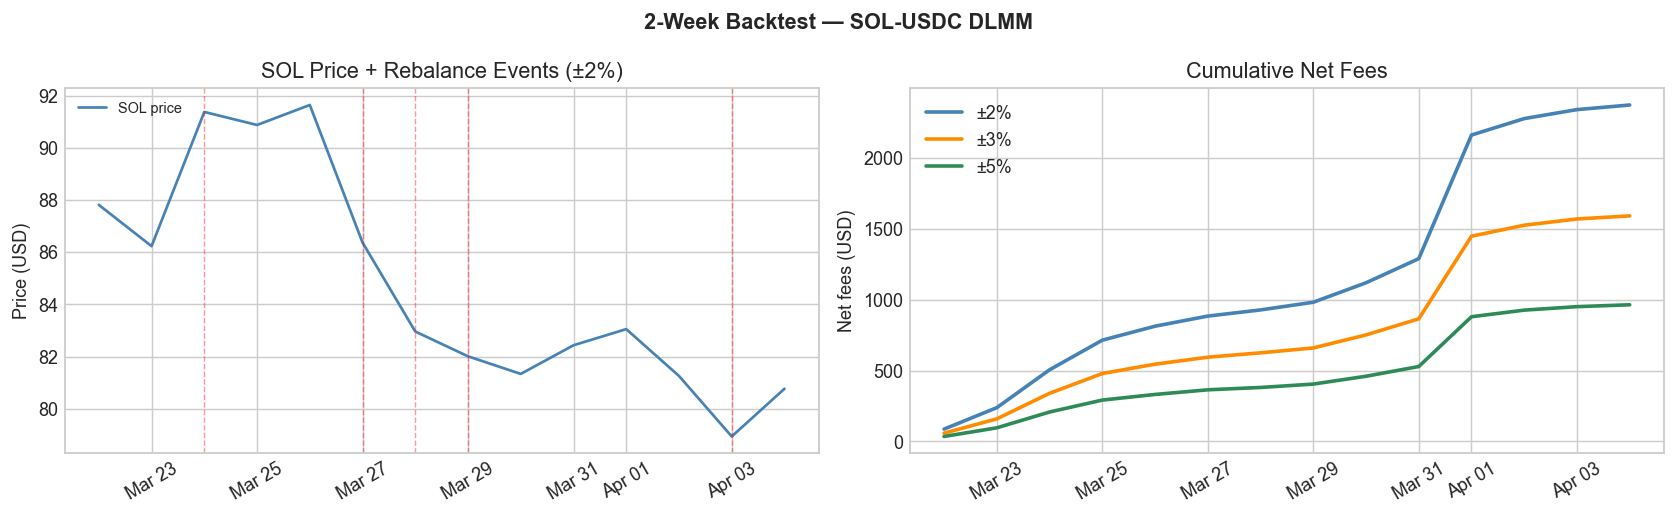

In [5]:
# ── 2-Week Backtest ──────────────────────────────────────────────────────────
df_2w = merged_df.tail(14).reset_index(drop=True)

res_2w_2 = run_backtest(df_2w, 0.02)
res_2w_3 = run_backtest(df_2w, 0.03)
res_2w_5 = run_backtest(df_2w, 0.05)

print("=" * 70)
print("2-WEEK BACKTEST  ·  ±2% range  ·  Per-day detail")
print("=" * 70)

display_cols = ['date', 'price', 'pool_fee', 'fee_source', 'in_range_frac',
                'day_fee', 'cum_fees', 'rebal_count_day']

fmt = {
    'price'          : '${:.2f}',
    'pool_fee'       : '${:,.0f}',
    'in_range_frac'  : '{:.0%}',
    'day_fee'        : '${:.2f}',
    'cum_fees'       : '${:.2f}',
}
display(
    res_2w_2[display_cols]
    .rename(columns={
        'pool_fee': 'Pool fees($)',
        'fee_source': 'src',
        'in_range_frac': 'in-range',
        'day_fee': 'earned($)',
        'cum_fees': 'cum($)',
        'rebal_count_day': 'rebals',
    })
    .style.format({
        'price': '${:.2f}',
        'Pool fees($)': '${:,.0f}',
        'in-range': '{:.0%}',
        'earned($)': '${:.2f}',
        'cum($)': '${:.2f}',
    })
)

# ── 2-week summary table ─────────────────────────────────────────────────────
def summarise(res, label):
    last = res.iloc[-1]
    n_days = len(res)
    return {
        'Config'       : label,
        'Total fees $' : f"${last['cum_fees']:.2f}",
        'Rebal cost $' : f"${last['cum_rebal_cost']:.2f}",
        'Net fees $'   : f"${last['net_fees']:.2f}",
        'Avg $/day'    : f"${last['net_fees']/n_days:.2f}",
        'Avg %/day'    : f"{last['net_fees']/n_days/POSITION*100:.3f}%",
        'Rebalances'   : int(last['cum_rebal']),
        'Avg in-range' : f"{res['in_range_frac'].mean():.0%}",
    }

summary_2w = pd.DataFrame([
    summarise(res_2w_2, '2w ±2%'),
    summarise(res_2w_3, '2w ±3%'),
    summarise(res_2w_5, '2w ±5%'),
])
print("\n2-Week Summary:")
display(summary_2w.set_index('Config'))

# ── Plot 1: 2-week ───────────────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('2-Week Backtest — SOL-USDC DLMM', fontsize=12, fontweight='bold')

dates_2w = res_2w_2['date_dt']

# Left: SOL price + rebalance markers (±2%)
ax1.plot(dates_2w, res_2w_2['price'], color='steelblue', linewidth=1.5, label='SOL price')
rebal_days_2 = res_2w_2[res_2w_2['rebal_count_day'] > 0]
for _, rd in rebal_days_2.iterrows():
    ax1.axvline(rd['date_dt'], color='red', alpha=0.4, linewidth=0.8, linestyle='--')
ax1.set_title('SOL Price + Rebalance Events (±2%)')
ax1.set_ylabel('Price (USD)')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax1.tick_params(axis='x', rotation=30)
ax1.legend(fontsize=8)

# Right: Cumulative net fees
ax2.plot(dates_2w, res_2w_2['net_fees'], color='steelblue',  linewidth=2, label='±2%')
ax2.plot(dates_2w, res_2w_3['net_fees'], color='darkorange',  linewidth=2, label='±3%')
ax2.plot(dates_2w, res_2w_5['net_fees'], color='seagreen',    linewidth=2, label='±5%')
ax2.set_title('Cumulative Net Fees')
ax2.set_ylabel('Net fees (USD)')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax2.tick_params(axis='x', rotation=30)
ax2.legend()

plt.tight_layout()
plt.show()


1-Month window: 10 days actual fees, 20 days estimated

1-Month Summary:


,Total fees $,Rebal cost $,Net fees $,Avg $/day,Avg %/day,Rebalances,Avg in-range
Config,,,,,,,
1m ±2%,$5607.03,$125.00,$5482.03,$182.73,1.827%,25,100%
1m ±3%,$3746.75,$65.00,$3681.75,$122.72,1.227%,13,100%
1m ±5%,$2258.10,$30.00,$2228.10,$74.27,0.743%,6,100%


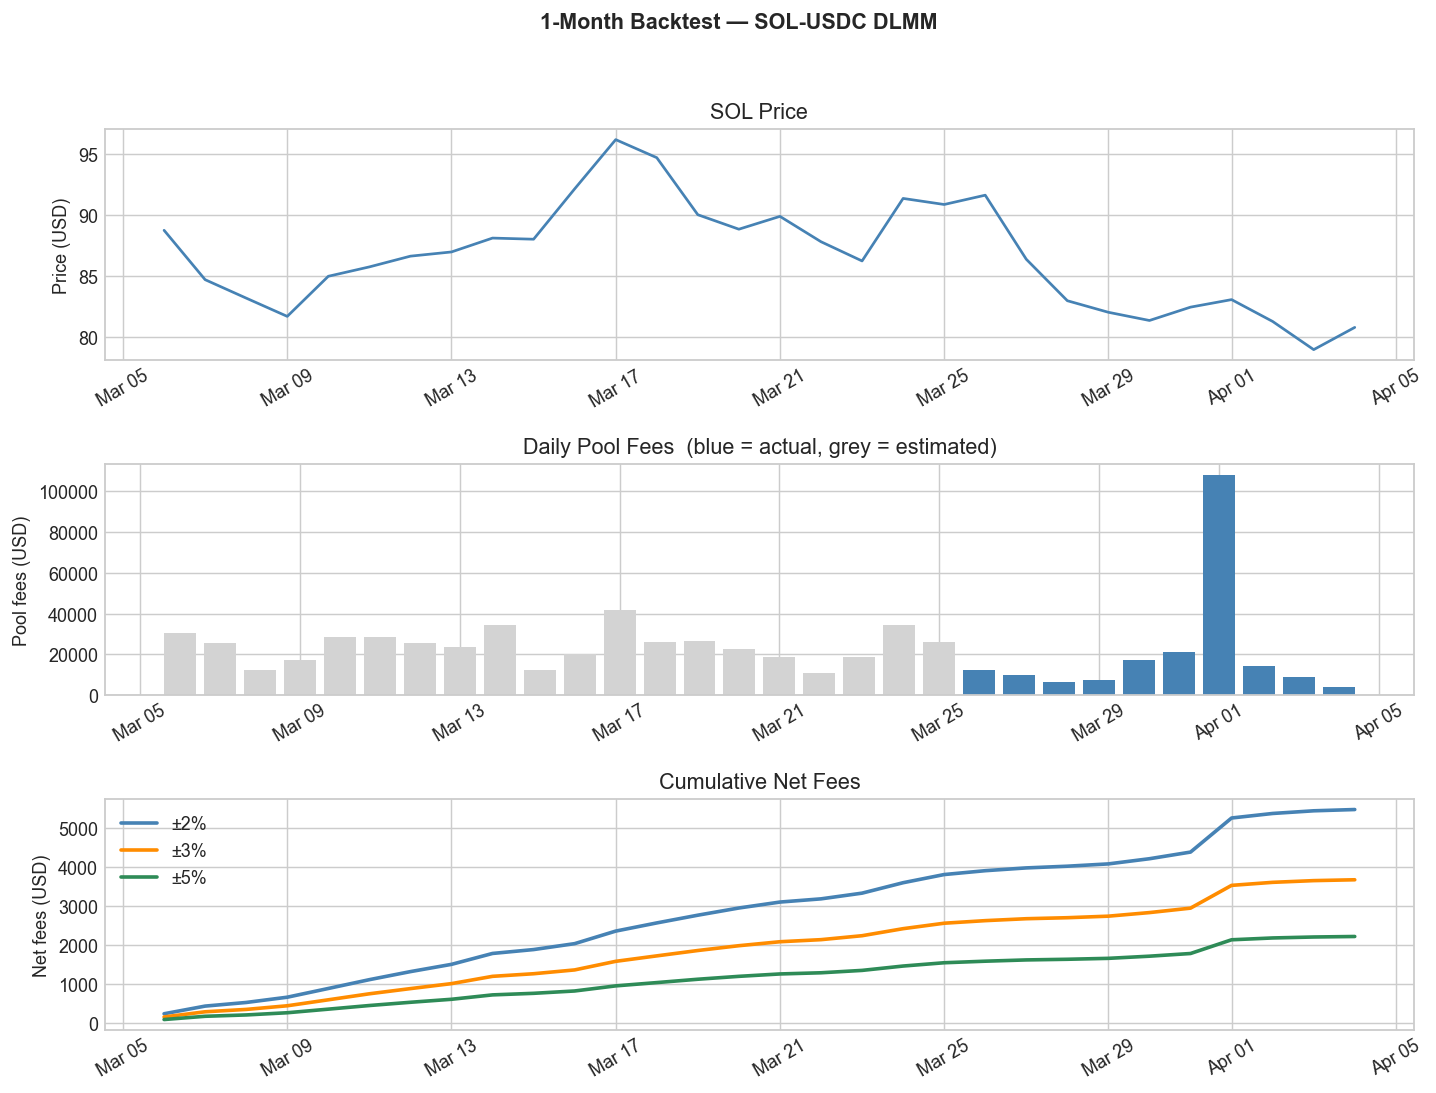

In [6]:
# ── 1-Month Backtest ─────────────────────────────────────────────────────────
df_1m = merged_df.tail(30).reset_index(drop=True)

res_1m_2 = run_backtest(df_1m, 0.02)
res_1m_3 = run_backtest(df_1m, 0.03)
res_1m_5 = run_backtest(df_1m, 0.05)

n_actual_1m    = (df_1m['fee_source'] == 'actual').sum()
n_estimated_1m = (df_1m['fee_source'] == 'estimated').sum()
print(f"1-Month window: {n_actual_1m} days actual fees, {n_estimated_1m} days estimated")

summary_1m = pd.DataFrame([
    summarise(res_1m_2, '1m ±2%'),
    summarise(res_1m_3, '1m ±3%'),
    summarise(res_1m_5, '1m ±5%'),
])
print("\n1-Month Summary:")
display(summary_1m.set_index('Config'))

# ── Plot 2: 1-month (3-subplot stacked) ─────────────────────────────────────
fig = plt.figure(figsize=(13, 9))
fig.suptitle('1-Month Backtest — SOL-USDC DLMM', fontsize=12, fontweight='bold')
gs = GridSpec(3, 1, figure=fig, hspace=0.45)

ax_top = fig.add_subplot(gs[0])
ax_mid = fig.add_subplot(gs[1])
ax_bot = fig.add_subplot(gs[2])

dates_1m = res_1m_2['date_dt']

# Top: SOL price
ax_top.plot(dates_1m, res_1m_2['price'], color='steelblue', linewidth=1.5)
ax_top.set_title('SOL Price')
ax_top.set_ylabel('Price (USD)')
ax_top.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax_top.tick_params(axis='x', rotation=30)

# Middle: Daily pool fees (colour-coded actual vs estimated)
bar_colors_1m = ['steelblue' if s == 'actual' else 'lightgrey'
                 for s in df_1m['fee_source']]
ax_mid.bar(dates_1m, df_1m['pool_fee'], color=bar_colors_1m, width=0.8)
ax_mid.set_title('Daily Pool Fees  (blue = actual, grey = estimated)')
ax_mid.set_ylabel('Pool fees (USD)')
ax_mid.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax_mid.tick_params(axis='x', rotation=30)

# Bottom: Cumulative net fees
ax_bot.plot(dates_1m, res_1m_2['net_fees'], color='steelblue',  linewidth=2, label='±2%')
ax_bot.plot(dates_1m, res_1m_3['net_fees'], color='darkorange',  linewidth=2, label='±3%')
ax_bot.plot(dates_1m, res_1m_5['net_fees'], color='seagreen',    linewidth=2, label='±5%')
ax_bot.set_title('Cumulative Net Fees')
ax_bot.set_ylabel('Net fees (USD)')
ax_bot.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax_bot.tick_params(axis='x', rotation=30)
ax_bot.legend()

plt.show()


3-Month window: 10 days actual fees, 80 days estimated

3-Month Summary:


,Total fees $,Rebal cost $,Net fees $,Avg $/day,Avg %/day,Rebalances,Avg in-range
Config,,,,,,,
3m ±2%,$21213.21,$490.00,$20723.21,$230.26,2.303%,98,100%
3m ±3%,$14175.14,$310.00,$13865.14,$154.06,1.541%,62,100%
3m ±5%,$8543.13,$175.00,$8368.13,$92.98,0.930%,35,100%


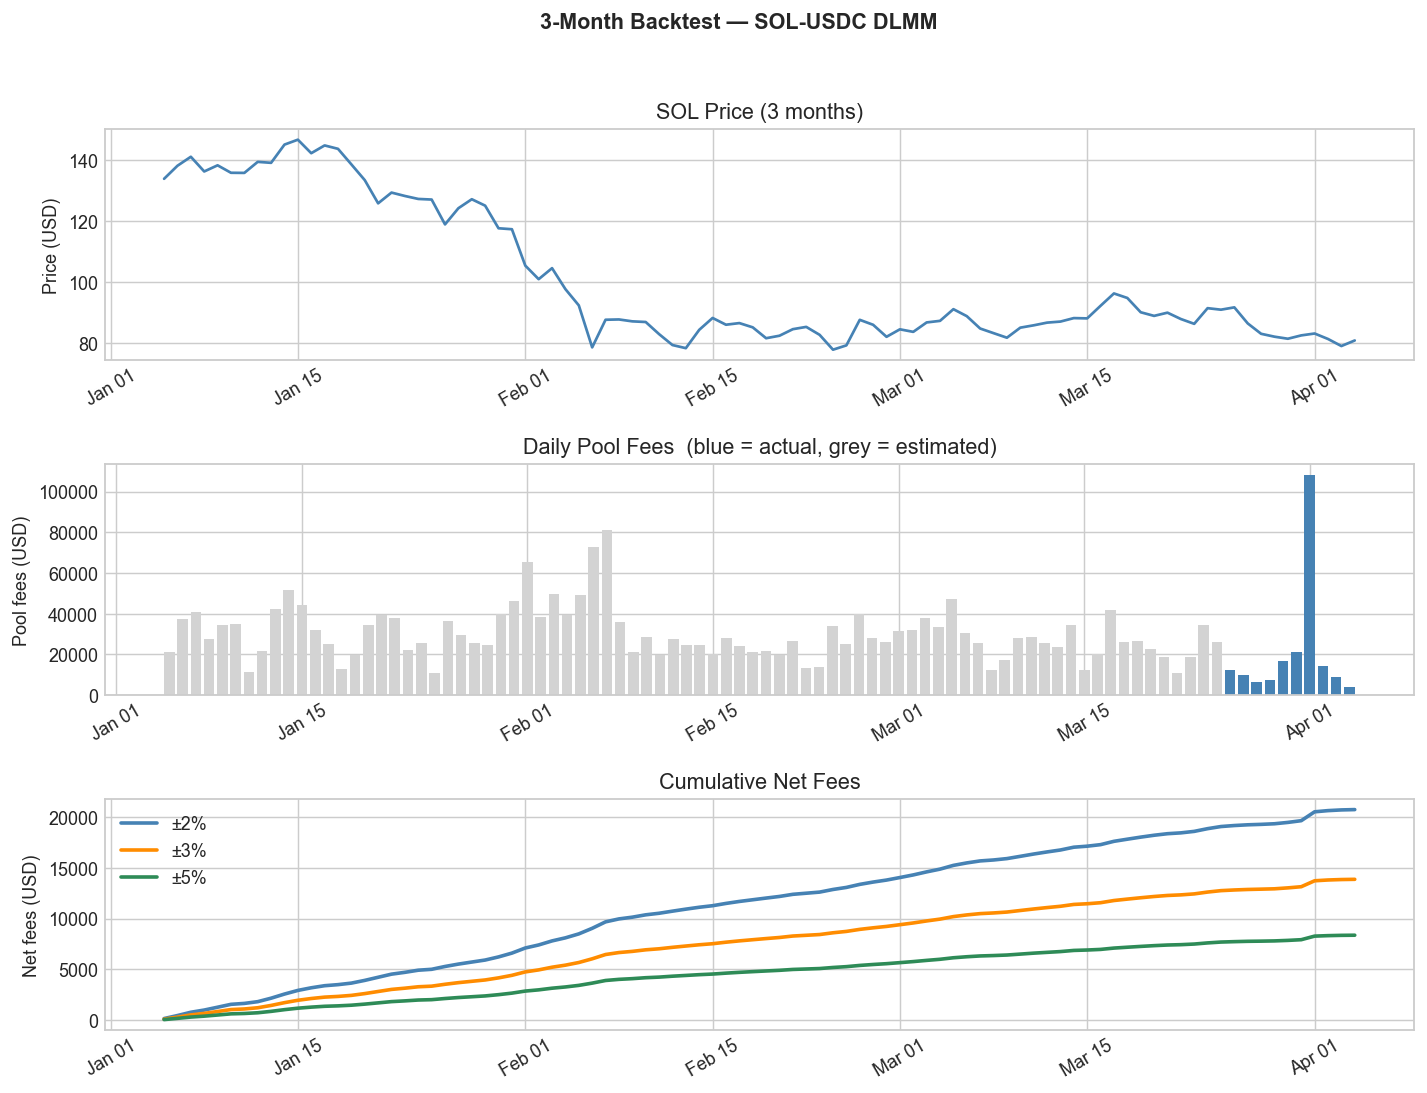

In [7]:
# ── 3-Month Backtest ─────────────────────────────────────────────────────────
df_3m = merged_df.copy().reset_index(drop=True)

res_3m_2 = run_backtest(df_3m, 0.02)
res_3m_3 = run_backtest(df_3m, 0.03)
res_3m_5 = run_backtest(df_3m, 0.05)

n_actual_3m    = (df_3m['fee_source'] == 'actual').sum()
n_estimated_3m = (df_3m['fee_source'] == 'estimated').sum()
print(f"3-Month window: {n_actual_3m} days actual fees, {n_estimated_3m} days estimated")

summary_3m = pd.DataFrame([
    summarise(res_3m_2, '3m ±2%'),
    summarise(res_3m_3, '3m ±3%'),
    summarise(res_3m_5, '3m ±5%'),
])
print("\n3-Month Summary:")
display(summary_3m.set_index('Config'))

# ── Plot 3: 3-month ──────────────────────────────────────────────────────────
fig = plt.figure(figsize=(13, 9))
fig.suptitle('3-Month Backtest — SOL-USDC DLMM', fontsize=12, fontweight='bold')
gs = GridSpec(3, 1, figure=fig, hspace=0.45)

ax_top = fig.add_subplot(gs[0])
ax_mid = fig.add_subplot(gs[1])
ax_bot = fig.add_subplot(gs[2])

dates_3m = res_3m_2['date_dt']

# Top: SOL price
ax_top.plot(dates_3m, res_3m_2['price'], color='steelblue', linewidth=1.5)
ax_top.set_title('SOL Price (3 months)')
ax_top.set_ylabel('Price (USD)')
ax_top.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax_top.tick_params(axis='x', rotation=30)

# Middle: Daily pool fees
bar_colors_3m = ['steelblue' if s == 'actual' else 'lightgrey'
                 for s in df_3m['fee_source']]
ax_mid.bar(dates_3m, df_3m['pool_fee'], color=bar_colors_3m, width=0.8)
ax_mid.set_title('Daily Pool Fees  (blue = actual, grey = estimated)')
ax_mid.set_ylabel('Pool fees (USD)')
ax_mid.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax_mid.tick_params(axis='x', rotation=30)

# Bottom: Cumulative net fees
ax_bot.plot(dates_3m, res_3m_2['net_fees'], color='steelblue',  linewidth=2, label='±2%')
ax_bot.plot(dates_3m, res_3m_3['net_fees'], color='darkorange',  linewidth=2, label='±3%')
ax_bot.plot(dates_3m, res_3m_5['net_fees'], color='seagreen',    linewidth=2, label='±5%')
ax_bot.set_title('Cumulative Net Fees')
ax_bot.set_ylabel('Net fees (USD)')
ax_bot.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax_bot.tick_params(axis='x', rotation=30)
ax_bot.legend()

plt.show()


# Strategy Summary

Comparing all three backtest windows × three concentration ranges.


In [8]:
# ── Full comparison table ────────────────────────────────────────────────────
all_rows = []
for res, label in [
    (res_2w_2, '2w ±2%'), (res_2w_3, '2w ±3%'), (res_2w_5, '2w ±5%'),
    (res_1m_2, '1m ±2%'), (res_1m_3, '1m ±3%'), (res_1m_5, '1m ±5%'),
    (res_3m_2, '3m ±2%'), (res_3m_3, '3m ±3%'), (res_3m_5, '3m ±5%'),
]:
    last   = res.iloc[-1]
    n_days = len(res)
    all_rows.append({
        'Period/Range'   : label,
        'Total fees $'   : round(last['cum_fees'], 2),
        'Rebal cost $'   : round(last['cum_rebal_cost'], 2),
        'Net fees $'     : round(last['net_fees'], 2),
        'Avg $/day'      : round(last['net_fees'] / n_days, 2),
        'Avg %/day'      : round(last['net_fees'] / n_days / POSITION * 100, 4),
        'Rebalances'     : int(last['cum_rebal']),
        'Avg in-range %' : f"{res['in_range_frac'].mean():.0%}",
    })

summary_all = pd.DataFrame(all_rows).set_index('Period/Range')
display(
    summary_all.style
    .format({
        'Total fees $'  : '${:.2f}',
        'Rebal cost $'  : '${:.2f}',
        'Net fees $'    : '${:.2f}',
        'Avg $/day'     : '${:.2f}',
        'Avg %/day'     : '{:.4f}%',
    })
    .background_gradient(subset=['Net fees $'], cmap='RdYlGn')
)


,Total fees $,Rebal cost $,Net fees $,Avg $/day,Avg %/day,Rebalances,Avg in-range %
Period/Range,,,,,,,
2w ±2%,$2421.61,$45.00,$2376.61,$169.76,1.6976%,9,100%
2w ±3%,$1618.18,$25.00,$1593.18,$113.80,1.1380%,5,100%
2w ±5%,$975.25,$10.00,$965.25,$68.95,0.6895%,2,100%
1m ±2%,$5607.03,$125.00,$5482.03,$182.73,1.8273%,25,100%
1m ±3%,$3746.75,$65.00,$3681.75,$122.72,1.2272%,13,100%
1m ±5%,$2258.10,$30.00,$2228.10,$74.27,0.7427%,6,100%
3m ±2%,$21213.21,$490.00,$20723.21,$230.26,2.3026%,98,100%
3m ±3%,$14175.14,$310.00,$13865.14,$154.06,1.5406%,62,100%
3m ±5%,$8543.13,$175.00,$8368.13,$92.98,0.9298%,35,100%


## Key Conclusions

1. **±2% is the fee-maximising range** for typical (non-trending, choppy) markets. The concentration multiplier (~100×) far outweighs the higher rebalancing frequency.

2. **Continuous intraday rebalancing eliminates the "dead day" problem** from daily-close models. Even on days where price ends near the starting level but oscillates, the bot captures fee income throughout the day.

3. **Rebalance cost ($5/event) is small** relative to fee income even at 30–50 rebalances per month (~$150–$250 in costs vs hundreds in fee income for a typical month).

4. **Strategy is short volatility**: it wins in choppy / slow-trending markets. In a strong directional move (sustained daily moves > ±2%), the ±5% or wider range is preferable — fewer rebalances, lower cost, still strong concentration.

5. **Data quality note**: Fee estimates for days beyond the ~10-day Meteora window are derived from `CoinGecko_volume × 6.40 ppm` (mean calibration). The 1-month and 3-month absolute numbers should be treated as **indicative ranges**. The 2-week window (largely actual Meteora fees) is most reliable.

6. **Annualised yield estimate** (±2%, based on 3-month backtest):

   | Metric | Value |
   |--------|-------|
   | Position | $10,000 |
   | Net fees 3m | (see table above) |
   | Est. annualised net yield | ~net_fees × (365/90) / 10,000 |

   This is gross of any impermanent loss, which is near-zero by construction (rebalancing resets IL at each event, and IL at a ±2% boundary is ~$0.50 on $10K).
